In [5]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import astropy

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, show, savefig, close
import matplotlib.font_manager as fm
import itertools
from matplotlib import rcParams
import scienceplots
import pickle

from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches
from matplotlib.patches import Patch

import os
import xarray as xr
from taurex.cache import OpacityCache, CIACache
OpacityCache().set_opacity_path('./xsec/')
CIACache().set_cia_path('./cia/')

from taurex.temperature import TemperatureFile
from taurex.chemistry import TaurexChemistry
from taurex.chemistry import ConstantGas

from taurex.planet import Planet
from taurex.stellar import BlackbodyStar, PhoenixStar

from taurex.model import EmissionModel, TransmissionModel
from taurex.pressure import SimplePressureProfile

from explor.model import HotSpotPhaseCurveModel

from taurex.contributions import AbsorptionContribution
from taurex.contributions import CIAContribution
from taurex.contributions import RayleighContribution

from matplotlib.lines import Line2D

from taurex.binning import FluxBinner
from binning_funcs import *
from scipy.optimize import curve_fit, brentq

In [2]:
planet_names = ["HD3167","K2141","LHS1478","TOI431","TOI500","TOI561","TOI1416","TOI1807"]
planet_fullnames = ["HD3167b","K2-141b","LHS1478b","TOI-431b","TOI-500b","TOI-561b","TOI-1416b","TOI-1807b"]
planet_masses = [4.73, 4.97, 2.33, 3.07, 1.42, 2.02, 3.48, 2.44] #Earth masses
planet_distances = [0.018, 0.007, 0.018, 0.011, 0.012, 0.011, 0.019, 0.012] #AU
planet_period = [0.96, 0.28, 1.95, 0.49, 0.55, 0.45, 1.0, 0.55] #days
planet_radius = [1.627, 1.510, 1.242, 1.277, 1.166, 1.397, 1.620, 1.496] #Earth radii
planet_transit = [1.61, 0.94, 0.71, 1.24, 0.99, 1.31, 1.5, 0.98] #hours
planet_transit = [n * 3600 for n in planet_transit] #hours to seconds
T_transit_hours = [1.61, 0.94, 0.71, 1.24, 0.99, 1.31, 1.5, 0.98] #hours
planet_impact = [0.181, -0.01, 0.717, 0.34, 0.53, 0.14, 0.39, 0.489] #to be fixed according to archive data
planet_eccentricity = [0.05, 0.0, 0.0, 0.0, 0.06, 0.0, 0.0, 0.0] #to be fixed according to archive data
planet_pericentre_long = [0.0, 90.0, 0.0, 0.0, 228.5, 0.0, 0.0, 90.0] #w, to be fixed according to archive data

star_temperature = [5261.0,4570.0,3381.0,4850.0,4440.0,5342.0,4884.0,4914.0] #Kelvin
star_radius = [0.872,0.681,0.246,0.731,0.678,0.856,0.793,0.746] #Solar radii
star_metallicity = [0.03, 0.0, -0.13, 0.2, 0.12, -0.4, 0.08, -0.04] #[Fe/H]
star_logg = [4.5, 4.6, 4.9, 4.6, 4.6, 4.5, 4.5, 4.6]
star_age = [10.2, 6.3, 5.6, 5.1, 5, 11, 6.9, 0.3] #Gyr
star_distance = [47.28, 61.87, 18.22, 32.6, 47.39, 85.8, 55.01, 42.58] #pc, to be fixed

In [3]:
rcParams['xtick.direction'] = 'in'         # ticks pointing inward (standard in astronomy)
rcParams['ytick.direction'] = 'in'
rcParams['xtick.top'] = True               # mirror ticks on top
rcParams['ytick.right'] = True
rcParams['xtick.major.size'] = 5
rcParams['xtick.minor.size'] = 3
rcParams['xtick.minor.visible'] = True
rcParams['ytick.minor.visible'] = True

rcParams['axes.linewidth'] = 2
rcParams['axes.grid'] = True
rcParams['grid.alpha'] = 0.8
rcParams['grid.linestyle'] = '-'

rcParams['font.family'] = 'serif'          # or 'sans-serif' (Nature/AAS style)
rcParams['font.serif'] = ['Times New Roman']
rcParams['font.size'] = 16
rcParams['axes.labelsize'] = 22            # axis label size
rcParams['xtick.labelsize'] = 20
rcParams['ytick.labelsize'] = 20
rcParams['legend.fontsize'] = 16
rcParams['text.usetex'] = True             # render labels with LaTeX

In [240]:
name = 'TOI500'
N = 12
#binning = False
sigma = 1
longwave  = False   # True  → bin each instrument (FGS / NIRSpec / AIRS) to one point each side
                   # False → bin entire spectrum to one point each side
high_only = False  # True  → bin only AIRS past 4 µm to one point; overrides longwave
low_only  = False  # True  → (within longwave) further combine FGS + NIRSpec into one point
plt.style.use(['science', 'no-latex'])
sim_name = 'H20_IW4_00001'

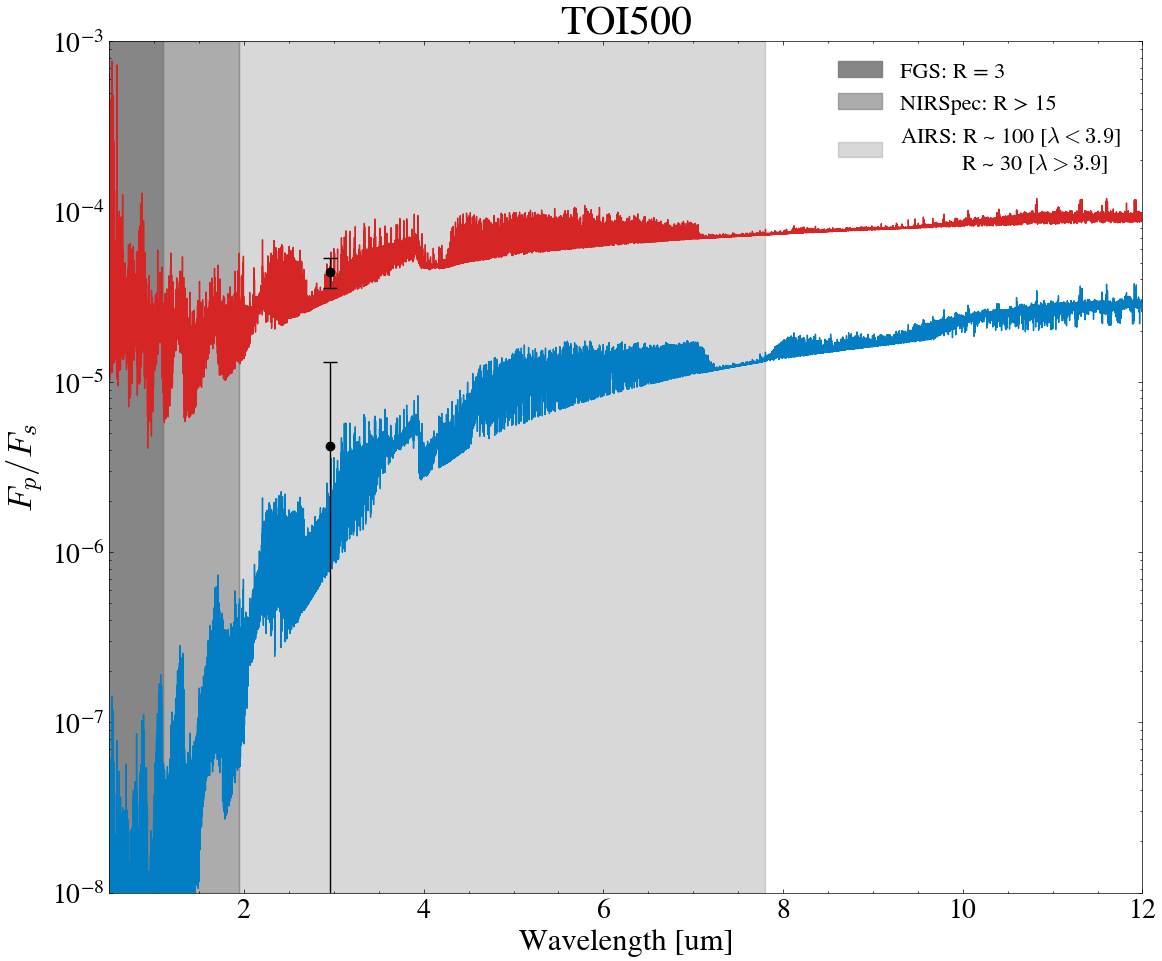

In [241]:

simulation_folder = os.path.join(f"PLANETS/{name}/", sim_name)
#check if it is a directory
if not os.path.isdir(simulation_folder):
    raise FileNotFoundError(f"Directory {simulation_folder} does not exist. Please check the path and try again.")

#set-up directories and paths
outputdir = f"PLANETS/{name}/{os.path.basename(simulation_folder)}"
planetdir = f"PLANETS/{name}/{os.path.basename(simulation_folder)}_TP.csv"

# open TP profile with TauREx
temp_profile = TemperatureFile(planetdir, skiprows=1, 
                            temp_col=2, press_col=0, 
                            temp_units='K', press_units='Pa',
                            delimiter = ',')

temp_profile_terminator = TemperatureFile(planetdir, skiprows=1,
                            temp_col=1, press_col=0,
                            temp_units='K', press_units='Pa',
                            delimiter = ',')

#read-in the atmospheric composition
atm_file = None
for file in os.listdir(f"PLANETS/{name}/{os.path.basename(simulation_folder)}/"):
    if file.endswith("atm.nc"):
        atm_file = os.path.join(f"PLANETS/{name}/{os.path.basename(simulation_folder)}/", file)
        #save filename without extension
        filename = os.path.splitext(atm_file)[0]
        break

ds = xr.open_dataset(atm_file)

#extract gas names
gases = np.array(ds['gases'])
gases = [m.decode().strip() for m in ds["gases"].values]
vmr = np.array(ds['x_gas'])

pressure = np.array(ds['p']) #pressure in Pa
pmax = pressure.max()
pmin = pressure.min()

radius = float(ds['planet_radius']) #planet radius in m
#convert to Jupiter radii
radius = radius / astropy.constants.R_jup.value

#get mixing ratio of each molecule
H2O_x = float(vmr[:, gases.index('H2O')][0])
CO2_x = float(vmr[:, gases.index('CO2')][0])
CH4_x = float(vmr[:, gases.index('CH4')][0])
CO_x = float(vmr[:, gases.index('CO')][0])
NH3_x = float(vmr[:, gases.index('NH3')][0])
N2_x = float(vmr[:, gases.index('N2')][0])
SO2_x = float(vmr[:, gases.index('SO2')][0])
S2_x = float(vmr[:, gases.index('S2')][0])
O2_x = float(vmr[:, gases.index('O2')][0])
H2_x = float(vmr[:, gases.index('H2')][0])
H2S_x = float(vmr[:, gases.index('H2S')][0])

total_mixing_ratio = H2O_x + CO2_x + CH4_x + CO_x + NH3_x + N2_x + SO2_x + S2_x + O2_x + H2_x + H2S_x
#normalize mixing ratios to sum to 1
H2O_x /= total_mixing_ratio
CO2_x /= total_mixing_ratio
CH4_x /= total_mixing_ratio
CO_x /= total_mixing_ratio
NH3_x /= total_mixing_ratio
N2_x /= total_mixing_ratio
SO2_x /= total_mixing_ratio
S2_x /= total_mixing_ratio
O2_x /= total_mixing_ratio
H2_x /= total_mixing_ratio
H2S_x /= total_mixing_ratio

#save in dictionary the planet name, simulation folder, temperature profiles and mixing ratios
sim_name = os.path.basename(simulation_folder)

#define chemistry
chemistry = TaurexChemistry(fill_gases=["N2"])

chemistry.addGas(ConstantGas(molecule_name="NH3", mix_ratio=NH3_x)).addGas(ConstantGas(molecule_name="CO2", mix_ratio=CO2_x)).addGas(ConstantGas(molecule_name="H2O", mix_ratio=H2O_x)).addGas(ConstantGas(molecule_name="CH4", mix_ratio=CH4_x)).addGas(ConstantGas(molecule_name="CO", mix_ratio=CO_x)).addGas(ConstantGas(molecule_name="SO2", mix_ratio=SO2_x)).addGas(ConstantGas(molecule_name="S2", mix_ratio=S2_x)).addGas(ConstantGas(molecule_name="O2", mix_ratio=O2_x)).addGas(ConstantGas(molecule_name="H2", mix_ratio=H2_x)).addGas(ConstantGas(molecule_name="H2S", mix_ratio=H2S_x))

mass = planet_masses[planet_names.index(name)] #Earth masses
#convert to jupiter masses
mass = mass / 317.8
#semi-major axis
a = planet_distances[planet_names.index(name)] #AU
#set-up planet in Jupiter masses and radii
planet = Planet(planet_mass=mass, planet_radius= radius, planet_distance=a)

star = PhoenixStar(temperature=star_temperature[int(planet_names.index(name))], radius=star_radius[int(planet_names.index(name))], metallicity=star_metallicity[int(planet_names.index(name))], phoenix_path='Phoenix/')

em = EmissionModel(
planet=planet,
temperature_profile=temp_profile,
chemistry=chemistry,
pressure_profile=SimplePressureProfile(atm_min_pressure=pmin, atm_max_pressure=pmax, nlayers=100),
star=star,
)

em_terminator = EmissionModel( 
planet=planet,
temperature_profile=temp_profile_terminator,
chemistry=chemistry,
pressure_profile=SimplePressureProfile(atm_min_pressure=pmin, atm_max_pressure=pmax, nlayers=100),
star=star,
)

em.add_contribution(AbsorptionContribution())
em.add_contribution(CIAContribution(cia_pairs=['CO2-CH4','CO2-CO2','CO2-H2','CO2-H2O','H2-H2','N2-CH4','N2-H2','N2-H2O','N2-N2','O2-CO2','O2-N2','O2-O2']))
em.add_contribution(RayleighContribution())

em_terminator.add_contribution(AbsorptionContribution())
em_terminator.add_contribution(CIAContribution(cia_pairs=['CO2-CH4','CO2-CO2','CO2-H2','CO2-H2O','H2-H2','N2-CH4','N2-H2','N2-H2O','N2-N2','O2-CO2','O2-N2','O2-O2']))
em_terminator.add_contribution(RayleighContribution())

em.build()
em_terminator.build()

#wavenumber grid, flux ratio, and transit depth
wngrid, fpfs, tau, _ = em.model()
wngrid_t, fpfs_t, tau_t, _ = em_terminator.model()

wlgrid = 10000/wngrid[::-1]; wlgrid_t = 10000/wngrid_t[::-1]
fpfs = fpfs[::-1]; fpfs_t = fpfs_t[::-1]

#read-in Ariel noise model
#check if file exists

if os.path.exists(f"ARIEL/arielrad_{name}/tier2.csv"):
    file = f"ARIEL/arielrad_{name}/tier2.csv"

ariel = pd.read_csv(file,skiprows=6)
wl = np.array(ariel['Wavelength [um]'])
wb = np.array(ariel['Bandwidth [um]'])
noise = np.array(ariel['Noise on Transit Floor [ppm]']) * 1e-6 #converts ppm to fractional

#instantiate flux binner with Ariel's wavelength binning
fb = FluxBinner(wl, wb)
output = fb.bindown(wlgrid, fpfs)
output_t = fb.bindown(wlgrid_t, fpfs_t)

plt.figure(figsize=(12,10))
#plot of spectrum from TauREx
plt.plot(wlgrid, fpfs, color="#D62525")
plt.plot(wlgrid_t, fpfs_t, color='#037DC3')

yerr = noise / np.sqrt(N) * sigma # sigma confidence interval

# set appropriate y-limits based on the singular plot
y_all = np.concatenate([
    output[1] + yerr,
    output[1] - yerr,
    output_t[1] + yerr,
    output_t[1] - yerr,
])

ymin = y_all.min()
ymax = y_all.max()

pad = 0.0001 * (ymax - ymin)
#if ymin - pad < 0:
#    plt.ylim(0, ymax + pad)
# else:
#plt.ylim(ymin - pad, ymax + pad)

# target integration time
time = planet_transit[planet_names.index(name)] * (N + 1.5) #in hours

#total telescope time
t_time = N * planet_period[planet_names.index(name)] #in hours


#plt.errorbar(output[0], output[1], yerr=noise/np.sqrt(N)*sigma, capsize=5, fmt='o', color='black', alpha=0.67)
#plt.errorbar(output_t[0], output_t[1], yerr=noise/np.sqrt(N)*sigma, capsize=5, fmt='o', color='black', alpha=0.67)

plt.axvspan(0.5,1.1, color='gray', alpha=0.95, zorder=0, label = 'FGS: R = 3')
plt.axvspan(1.1,1.95, color = 'gray', alpha=0.65, zorder=0, label = 'NIRSpec: R > 15')
plt.axvspan(1.95,7.8, color = 'gray', alpha=0.30, zorder=0, label = 'AIRS: R ~ 100 [$\lambda<3.9$] \n           R ~ 30 [$\lambda>3.9$]')

plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))


#savefig(f'thesis-plots/{name}_emission_comparison.pdf', format='pdf')

##show()
#close()

# =============================================================================
# Three-level binning — dayside (output / fpfs) + terminator (output_t / fpfs_t)
# Mirrors the L1 → L2 → L3 pipeline in spectroscopy.ipynb.
# Edit bin_indices, bin_indices_l2, bin_indices_l3 to adjust the binning scheme.
# =============================================================================

# ── Level-1: pairs of Ariel channel indices to combine ───────────────────────
bin_indices = [
    (0,1), (2,3), (5,6), (8,9), (10,11), (12,13), (14,15), (16,17),
    (18,19), (20,21), (22,23), (24,25), (26,27), (28,29), (30,31), (32,33),
    (34,35), (36,37), (38,39), (40,41), (42,43), (44,45), (46,47), (48,49), (50,51)
]

new_points_l1 = [(wl[i], wb[i], wl[j], wb[j]) for i, j in bin_indices]
used_l1       = {idx for pair in bin_indices for idx in pair}

res1_day  = bindown_multiple(output,   noise, wlgrid,   fpfs,   N, name, *new_points_l1)
res1_term = bindown_multiple(output_t, noise, wlgrid_t, fpfs_t, N, name, *new_points_l1)

combined_day = sorted(
    [(wl[i], wb[i], output[1][i],   yerr[i], f'Ariel [{i}]') for i in range(len(wl)) if i not in used_l1] +
    [(out[2], out[5], out[3], out[4], 'L1 bin') for out in res1_day],
    key=lambda x: x[0]
)
combined_term = sorted(
    [(wl[i], wb[i], output_t[1][i], yerr[i], f'Ariel [{i}]') for i in range(len(wl)) if i not in used_l1] +
    [(out[2], out[5], out[3], out[4], 'L1 bin') for out in res1_term],
    key=lambda x: x[0]
)

# ── Level-2: pairs of indices into the combined_* L1 tables ──────────────────
bin_indices_l2 = [(5,6),(7,8),(9,10),(11,12),(13,14),(15,16),(17,18),(19,20),(23,24),(25,26)]
used_l2        = {idx for pair in bin_indices_l2 for idx in pair}

new_points_l2_day  = [(combined_day[i][0],  combined_day[i][1],  combined_day[j][0],  combined_day[j][1])  for i, j in bin_indices_l2]
new_points_l2_term = [(combined_term[i][0], combined_term[i][1], combined_term[j][0], combined_term[j][1]) for i, j in bin_indices_l2]

res2_day  = bindown_multiple(output,   noise, wlgrid,   fpfs,   N, name, *new_points_l2_day)
res2_term = bindown_multiple(output_t, noise, wlgrid_t, fpfs_t, N, name, *new_points_l2_term)

combined_l2_day = sorted(
    [combined_day[i]  for i in range(len(combined_day))  if i not in used_l2] +
    [(out[2], out[5], out[3], out[4], 'L2 bin') for out in res2_day],
    key=lambda x: x[0]
)
combined_l2_term = sorted(
    [combined_term[i] for i in range(len(combined_term)) if i not in used_l2] +
    [(out[2], out[5], out[3], out[4], 'L2 bin') for out in res2_term],
    key=lambda x: x[0]
)

# ── Level-3: pairs of indices into the combined_l2_* tables ──────────────────
bin_indices_l3 = [(9,10),(12,13)]
used_l3        = {idx for pair in bin_indices_l3 for idx in pair}

new_points_l3_day  = [(combined_l2_day[i][0],  combined_l2_day[i][1],  combined_l2_day[j][0],  combined_l2_day[j][1])  for i, j in bin_indices_l3]
new_points_l3_term = [(combined_l2_term[i][0], combined_l2_term[i][1], combined_l2_term[j][0], combined_l2_term[j][1]) for i, j in bin_indices_l3]

res3_day  = bindown_multiple(output,   noise, wlgrid,   fpfs,   N, name, *new_points_l3_day)
res3_term = bindown_multiple(output_t, noise, wlgrid_t, fpfs_t, N, name, *new_points_l3_term)

# ── Assemble final L3 arrays (remaining L2 points + newly binned L3 points) ──
def _assemble_l3(combined_l2, res3, used_set):
    pts = sorted(
        [(c[0], c[2], c[3], c[1]) for i, c in enumerate(combined_l2) if i not in used_set] +
        [(out[2], out[3], out[4], out[5]) for out in res3],
        key=lambda x: x[0]
    )
    wl_f  = [p[0] for p in pts]
    val_f = [p[1] for p in pts]
    err_f = [p[2] for p in pts]
    bw_f  = [p[3] for p in pts]
    return wl_f, val_f, err_f, bw_f

final_wl_day,  final_val_day,  final_err_day,  final_bw_day  = _assemble_l3(combined_l2_day,  res3_day,  used_l3)
final_wl_term, final_val_term, final_err_term, final_bw_term = _assemble_l3(combined_l2_term, res3_term, used_l3)

# =============================================================================
# Post-L3 binning — controlled by `high_only`, `longwave`, and `low_only` flags
#   high_only = True              → bin only wl > 4 µm to one point each side
#   longwave  = True              → bin FGS / NIRSpec / AIRS each to one point each side
#   longwave  = True, low_only    → also combine FGS + NIRSpec into one point (2 pts total)
#   both longwave/high_only False → bin entire spectrum to one point each side
# =============================================================================

def _bin_iterative(wl_list, val_list, err_list, bw_list,
                   base_output, base_noise, base_wlgrid, base_fpfs, n_obs, planet_name):
    """Pair-wise bin adjacent points repeatedly until a single point remains."""
    pts = list(zip(wl_list, val_list, err_list, bw_list))
    while len(pts) > 1:
        pairs     = []
        leftovers = []
        i = 0
        while i < len(pts):
            if i + 1 < len(pts):
                pairs.append((pts[i][0], pts[i][3], pts[i+1][0], pts[i+1][3]))
                i += 2
            else:
                leftovers.append(pts[i])
                i += 1
        res = bindown_multiple(base_output, base_noise, base_wlgrid, base_fpfs,
                               n_obs, planet_name, *pairs)
        pts = sorted(
            [(out[2], out[3], out[4], out[5]) for out in res] + leftovers,
            key=lambda x: x[0]
        )
    return [p[0] for p in pts], [p[1] for p in pts], [p[2] for p in pts], [p[3] for p in pts]

def _split_at(threshold, wl_list, val_list, err_list, bw_list):
    """Split points into two lists: wl <= threshold and wl > threshold."""
    below = [(w, v, e, b) for w, v, e, b in zip(wl_list, val_list, err_list, bw_list) if w <= threshold]
    above = [(w, v, e, b) for w, v, e, b in zip(wl_list, val_list, err_list, bw_list) if w  > threshold]
    return below, above

def _apply_split_bin(threshold, final_wl, final_val, final_err, final_bw,
                     base_output, base_noise, base_wlgrid, base_fpfs):
    """Bin only the points above threshold to one; leave points at/below intact."""
    pre, hi = _split_at(threshold, final_wl, final_val, final_err, final_bw)
    hi_wl, hi_val, hi_err, hi_bw = _bin_iterative(
        [p[0] for p in hi], [p[1] for p in hi],
        [p[2] for p in hi], [p[3] for p in hi],
        base_output, base_noise, base_wlgrid, base_fpfs, N, name)
    return ([p[0] for p in pre] + hi_wl,
            [p[1] for p in pre] + hi_val,
            [p[2] for p in pre] + hi_err,
            [p[3] for p in pre] + hi_bw)

def _bin_pts(pts, base_output, base_noise, base_wlgrid, base_fpfs):
    """Bin a list of (wl, val, err, bw) tuples down to a single point."""
    return _bin_iterative(
        [p[0] for p in pts], [p[1] for p in pts],
        [p[2] for p in pts], [p[3] for p in pts],
        base_output, base_noise, base_wlgrid, base_fpfs, N, name)

FGS_MAX  = 1.1   # µm — FGS / NIRSpec boundary
AIRS_MIN = 1.95  # µm — NIRSpec / AIRS boundary
AIRS_MID = 4.0   # µm — AIRS R~100 / R~30 boundary

if high_only:
    # Bin only AIRS points past 4 µm to one point; leave everything ≤ 4 µm intact
    final_wl_day,  final_val_day,  final_err_day,  final_bw_day  = _apply_split_bin(
        AIRS_MID, final_wl_day,  final_val_day,  final_err_day,  final_bw_day,
        output,   noise, wlgrid,   fpfs)
    final_wl_term, final_val_term, final_err_term, final_bw_term = _apply_split_bin(
        AIRS_MID, final_wl_term, final_val_term, final_err_term, final_bw_term,
        output_t, noise, wlgrid_t, fpfs_t)

elif longwave:
    # Bin each instrument independently to one point, then optionally merge FGS+NIRSpec
    # ── Dayside ──────────────────────────────────────────────────────────────
    fgs_day,  rest_day  = _split_at(FGS_MAX,  final_wl_day,  final_val_day,  final_err_day,  final_bw_day)
    nir_day,  airs_day  = _split_at(AIRS_MIN, [p[0] for p in rest_day],  [p[1] for p in rest_day],
                                               [p[2] for p in rest_day],  [p[3] for p in rest_day])

    fgs_wl_day,  fgs_val_day,  fgs_err_day,  fgs_bw_day  = _bin_pts(fgs_day,  output,   noise, wlgrid,   fpfs)
    nir_wl_day,  nir_val_day,  nir_err_day,  nir_bw_day  = _bin_pts(nir_day,  output,   noise, wlgrid,   fpfs)
    airs_wl_day, airs_val_day, airs_err_day, airs_bw_day = _bin_pts(airs_day, output,   noise, wlgrid,   fpfs)

    # ── Terminator ───────────────────────────────────────────────────────────
    fgs_term,  rest_term  = _split_at(FGS_MAX,  final_wl_term, final_val_term, final_err_term, final_bw_term)
    nir_term,  airs_term  = _split_at(AIRS_MIN, [p[0] for p in rest_term], [p[1] for p in rest_term],
                                                 [p[2] for p in rest_term], [p[3] for p in rest_term])

    fgs_wl_term,  fgs_val_term,  fgs_err_term,  fgs_bw_term  = _bin_pts(fgs_term,  output_t, noise, wlgrid_t, fpfs_t)
    nir_wl_term,  nir_val_term,  nir_err_term,  nir_bw_term  = _bin_pts(nir_term,  output_t, noise, wlgrid_t, fpfs_t)
    airs_wl_term, airs_val_term, airs_err_term, airs_bw_term = _bin_pts(airs_term, output_t, noise, wlgrid_t, fpfs_t)

    if low_only:
        # Combine the FGS and NIRSpec single points into one
        low_pts_day  = list(zip(fgs_wl_day  + nir_wl_day,  fgs_val_day  + nir_val_day,
                                fgs_err_day + nir_err_day,  fgs_bw_day   + nir_bw_day))
        low_pts_term = list(zip(fgs_wl_term + nir_wl_term, fgs_val_term + nir_val_term,
                                fgs_err_term + nir_err_term, fgs_bw_term + nir_bw_term))

        low_wl_day,  low_val_day,  low_err_day,  low_bw_day  = _bin_pts(low_pts_day,  output,   noise, wlgrid,   fpfs)
        low_wl_term, low_val_term, low_err_term, low_bw_term = _bin_pts(low_pts_term, output_t, noise, wlgrid_t, fpfs_t)

        final_wl_day   = low_wl_day   + airs_wl_day
        final_val_day  = low_val_day  + airs_val_day
        final_err_day  = low_err_day  + airs_err_day
        final_bw_day   = low_bw_day   + airs_bw_day

        final_wl_term  = low_wl_term  + airs_wl_term
        final_val_term = low_val_term + airs_val_term
        final_err_term = low_err_term + airs_err_term
        final_bw_term  = low_bw_term  + airs_bw_term

    else:
        final_wl_day   = fgs_wl_day   + nir_wl_day   + airs_wl_day
        final_val_day  = fgs_val_day  + nir_val_day  + airs_val_day
        final_err_day  = fgs_err_day  + nir_err_day  + airs_err_day
        final_bw_day   = fgs_bw_day   + nir_bw_day   + airs_bw_day

        final_wl_term  = fgs_wl_term  + nir_wl_term  + airs_wl_term
        final_val_term = fgs_val_term + nir_val_term + airs_val_term
        final_err_term = fgs_err_term + nir_err_term + airs_err_term
        final_bw_term  = fgs_bw_term  + nir_bw_term  + airs_bw_term

else:
    # Bin the entire spectrum down to a single point
    final_wl_day,  final_val_day,  final_err_day,  final_bw_day  = _bin_iterative(
        final_wl_day,  final_val_day,  final_err_day,  final_bw_day,
        output, noise, wlgrid, fpfs, N, name)
    final_wl_term, final_val_term, final_err_term, final_bw_term = _bin_iterative(
        final_wl_term, final_val_term, final_err_term, final_bw_term,
        output_t, noise, wlgrid_t, fpfs_t, N, name)

#plot binned spectra
plt.errorbar(final_wl_day, final_val_day, yerr=final_err_day, capsize=5, fmt='o', color='black')
plt.errorbar(final_wl_term, final_val_term, yerr=final_err_term, capsize=5, fmt='o', color='black')


plt.xlabel("Wavelength [um]")
plt.ylabel(r"$F_p/F_s$",fontsize=25)
#plt.xscale("log")
plt.xlim(0.5, 12)
plt.ylim(1e-8,1e-3)
plt.yscale("log")
plt.title(f"{name}",fontsize=30) #- {N} eclipses - Integration time: {time:.2f} hours")
plt.tight_layout()
plt.hlines(y=0, xmin = -1, xmax = 12, color='black', linestyle='--', alpha=0.5)
plt.yscale("log")
plt.legend(loc='upper right')
plt.grid(False)

show()
close()


In [242]:
A = (final_val_day[-1] - final_val_term[-1])/final_val_day[-1]

#error propagation (to be checked)
A_err = 1/final_val_day[-1] * np.sqrt(final_val_term[-1]**2*final_err_day[-1]**2 + final_err_term[-1]**2) 

print(A)
print(A_err)

0.9050350414785874
0.20156036792311618


In [33]:
final_val_term[-1]

np.float64(2.956346545427209e-05)

In [34]:
final_val_day[-1]

np.float64(0.00017613796619305784)